In [2]:
import numpy as np
import matplotlib.pyplot as plt

mu = 3.5316000e12 
R  = 600000.0

# time
t = np.linspace(0, 1000, 5000)
dt = t[1] - t[0]

# initial conditions
r0 = np.array([0.0, R])
vr0 = 1500.0
vt0 = 1500.0
v0 = np.array([vt0, vr0])

# -----------------------------
# 1. Flat trajectory (unchanged)
# -----------------------------
g0 = mu / R**2
g0v = np.array([0, -g0])

def flat_grav(vv0, dt, steps):
    x = np.zeros((steps, 2))
    
    r = np.array([0.0, 0.0])
    v = vv0.copy()
    a = g0v.copy()

    cutoff = steps

    for i in range(steps - 1):

        # kinematics (constant acceleration model)
        r_new = r + v*dt + 0.5*a*dt*dt

        # stop condition: hit ground
        if r_new[1] < 0:
            cutoff = i + 1
            x[i] = r_new
            break

        a_new = accel(r0)  # constant field

        v_new = v + 0.5*(a + a_new)*dt

        x[i+1] = r_new

        r, v, a = r_new, v_new, a_new

    return x[:cutoff]
flat = flat_grav(v0, dt, len(t))

plt.plot(flat.T[0],flat.T[1],'r-',lw=1)
plt.show()
# -----------------------------
# 2. Wrap onto circle
# -----------------------------
def wrap_to_circle(traj, R):
    x = traj[:, 0]
    y = traj[:, 1]

    theta = x / R
    r = R + y

    X = r * np.sin(theta)
    Y = r * np.cos(theta)
    return X, Y

wx, wy = wrap_to_circle(flat, R)

# -----------------------------
# 3. Velocity Verlet orbit WITH cutoff
# -----------------------------
def accel(r):
    return -mu * r / np.linalg.norm(r)**3

def vv_orbit_cutoff(r0, v0, dt, steps, R):
    r = np.zeros((steps, 2))
    v = np.zeros((steps, 2))

    r[0] = r0
    v[0] = v0

    a = accel(r0)

    cutoff_index = steps

    for i in range(steps - 1):

        # position update
        r_new = r[i] + v[i]*dt + 0.5*a*dt*dt

        # STOP CONDITION: radial distance below R
        if np.linalg.norm(r_new) < R:
            cutoff_index = i + 1
            r = r[:cutoff_index]
            v = v[:cutoff_index]
            break

        a_new = accel(r_new)

        # velocity update
        v_new = v[i] + 0.5*(a + a_new)*dt

        r[i+1] = r_new
        v[i+1] = v_new
        a = a_new

    return r

orbit = vv_orbit_cutoff(r0, v0, dt, len(t), R)

# -----------------------------
# 4. Circle
# -----------------------------
theta_c = np.linspace(0, 2*np.pi, 500)
circle_x = R * np.sin(theta_c)
circle_y = R * np.cos(theta_c)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,8))

plt.plot(wx, wy, lw=1, label="Wrapped flat trajectory")
plt.plot(orbit[:,0], orbit[:,1], lw=1, label="Kepler orbit (Velocity Verlet, cutoff)")
plt.plot(circle_x, circle_y, '--', label="Circle radius R")

plt.scatter([0], [R], c='black', s=20, label="Initial point (0,R)")

plt.axis("equal")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Wrapped trajectory vs VV orbit (cut at r < R)")
plt.show()

NameError: name 'accel' is not defined

          x          y
0  1.650000  10.000000
1  1.624885  10.575228
2  1.549731  11.146078
3  1.425110  11.708206
4  1.251971  12.257333
5  1.031631  12.789281
6  0.765768  13.300000
7  0.456403  13.785604
8  0.105893  14.242398


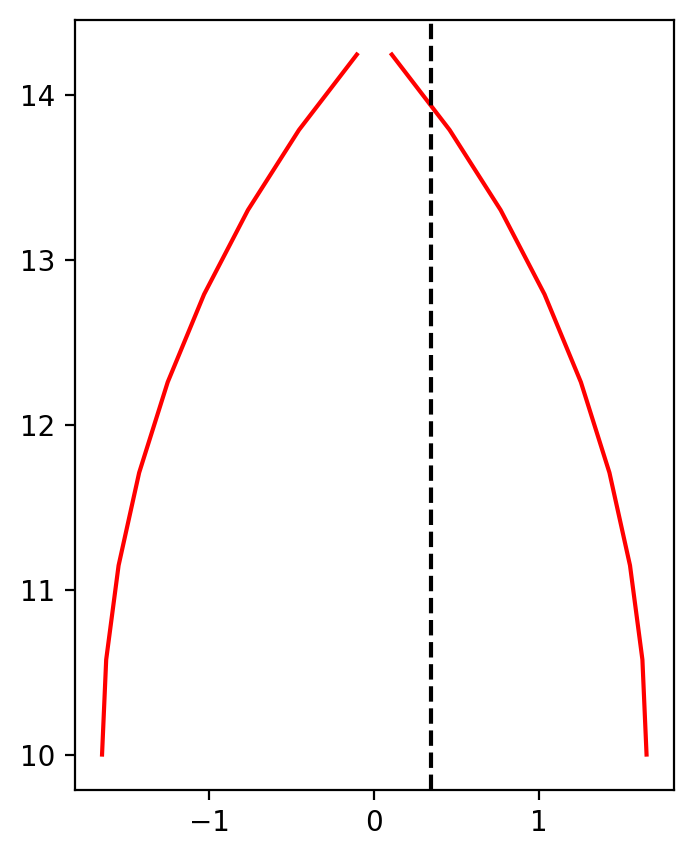

np.float64(14.127650663513084)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

theta = np.deg2rad(np.arange(0,45,5))
Rr = 3.3/2
r = Rr * 4 
x = r * np.cos(theta) - Rr * 3
y = r * np.sin(theta) + 10

# Create DataFrame with x and y values
df = pd.DataFrame({
    'x': x,
    'y': y
})

print(df)

# Plot (your original code)
plt.figure(figsize = (5,5), dpi = 200)
plt.plot(x,y,'r-')
plt.plot(-x,y,'r-')
plt.gca().set_aspect("equal")
# plt.xlim(0,2)
plt.axvline(0.345,ls='--',color="k")
plt.show()

np.sqrt(r**2 - (0.2 + Rr * 3)**2) + 10

In [ ]:
x = 3.3/2 - 1.25 
th = np.deg2rad(30)
print(x/np.tan(th))